# House Price Prediction — Simple Linear Regression (from scratch)
Model: `y_pred = w*x + b`, trained using Gradient Descent (no sklearn).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

## 1. Data Load

In [24]:
# Dataset load karo
df = pd.read_csv("kc_house_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 2. Feature aur Target Select Karo

In [25]:
# Feature (x) aur target (y) select karo
# x = sqft_living, y = price
x = df["sqft_living"].values
y = df["price"].values

## 3. Normalization

In [26]:
# Normalization (Feature Scaling)
x_mean, x_std = x.mean(), x.std()
y_mean, y_std = y.mean(), y.std()

x_norm = (x - x_mean) / x_std
y_norm = (y - y_mean) / y_std

n = len(y)

## 4. Parameters Initialize Karo

In [27]:
# Parameters initialize karo (w, b)
rd.seed(42)
w = rd.uniform(-1, 1)
b = rd.uniform(-1, 1)

print(f"Initial parameters -> w: {w:.4f}, b: {b:.4f}")

Initial parameters -> w: 0.2789, b: -0.9500


## 5. Hyperparameters

In [28]:
# Hyperparameters
learning_rate = 0.01
epochs = 1000

loss_history = []

## 6. Training Loop

In [29]:
# Training loop (Gradient Descent)
# Model: y_pred = w*x + b
for epoch in range(epochs):
    # Prediction
    y_pred = w * x_norm + b

    # Error
    error = y_pred - y_norm

    # Loss (Mean Squared Error)
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Gradients
    dw = (2 / n) * np.sum(error * x_norm)
    db = (2 / n) * np.sum(error)

    # Parameters update karo
    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.6f} | w: {w:.4f} | b: {b:.4f}")

print(f"\nFinal parameters -> w: {w:.4f}, b: {b:.4f}")
print(f"Final Loss: {loss_history[-1]:.6f}")

Epoch    0 | Loss: 1.588688 | w: 0.2873 | b: -0.9310
Epoch  100 | Loss: 0.526169 | w: 0.6470 | b: -0.1235
Epoch  200 | Loss: 0.507481 | w: 0.6947 | b: -0.0164
Epoch  300 | Loss: 0.507153 | w: 0.7011 | b: -0.0022
Epoch  400 | Loss: 0.507147 | w: 0.7019 | b: -0.0003
Epoch  500 | Loss: 0.507147 | w: 0.7020 | b: -0.0000
Epoch  600 | Loss: 0.507147 | w: 0.7020 | b: -0.0000
Epoch  700 | Loss: 0.507147 | w: 0.7020 | b: -0.0000
Epoch  800 | Loss: 0.507147 | w: 0.7020 | b: -0.0000
Epoch  900 | Loss: 0.507147 | w: 0.7020 | b: -0.0000

Final parameters -> w: 0.7020, b: -0.0000
Final Loss: 0.507147


## 7. Loss Curve

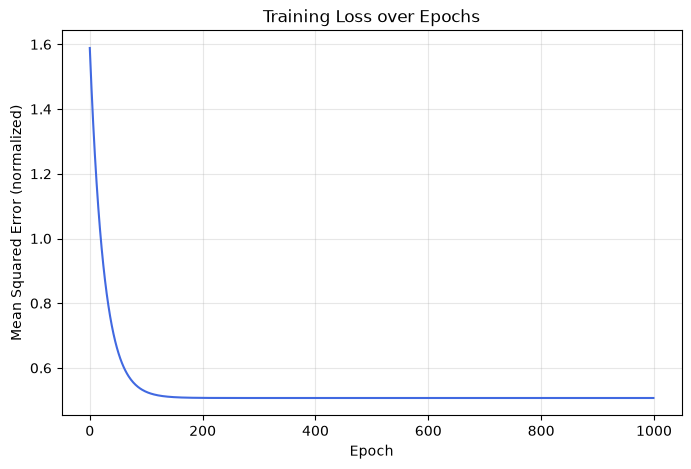

In [30]:
# Loss curve plot karo
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color="royalblue")
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (normalized)")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Regression Line Plot

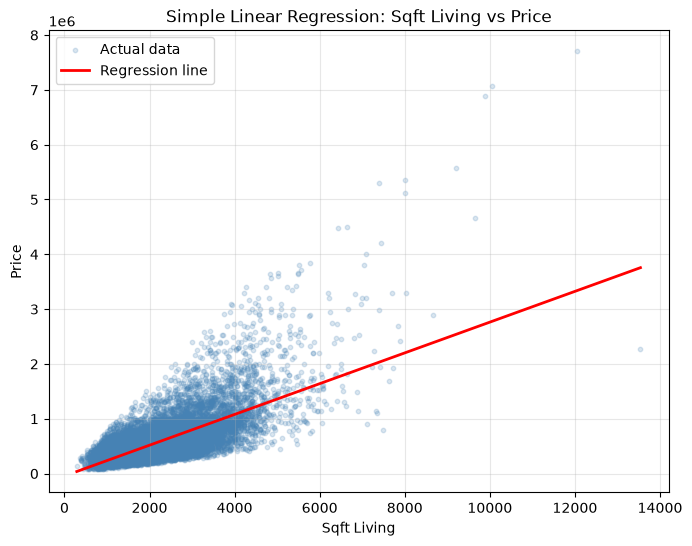

In [31]:
# Regression line plot karo (data + fitted line)
y_pred_final_norm = w * x_norm + b
y_pred_final = y_pred_final_norm * y_std + y_mean

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.2, s=10, color="steelblue", label="Actual data")
sort_idx = np.argsort(x)
plt.plot(x[sort_idx], y_pred_final[sort_idx], color="red", linewidth=2, label="Regression line")
plt.xlabel("Sqft Living")
plt.ylabel("Price")
plt.title("Simple Linear Regression: Sqft Living vs Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. R² Score

In [32]:
# R^2 Score (model accuracy check karne k liye)
ss_res = np.sum((y - y_pred_final) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2_score = 1 - (ss_res / ss_tot)
print(f"R^2 Score: {r2_score:.4f}")

R^2 Score: 0.4929


## 10. Prediction Function

In [33]:
# Naye data par prediction ka function
def predict_price(sqft_living):
    x_n = (sqft_living - x_mean) / x_std
    pred_norm = w * x_n + b
    return pred_norm * y_std + y_mean

# Example
example_price = predict_price(2000)
print(f"Example: 2000 sqft wale ghar ki predicted price: ${example_price:,.2f}")

Example: 2000 sqft wale ghar ki predicted price: $517,666.39
